# House Sales in King County, USA
# Predict house price using regression

# King County House Price Prediction

**Author:** Tan Han Rong
**Course:** Specialist Diploma in Data Science (AI), Singapore Polytechnic
**Dataset:** [Kaggle — House Sales in King County](https://www.kaggle.com/harlfoxem/housesalesprediction)

## Objective
Predict house sale prices in King County, USA (May 2014 – May 2015)
using regression models. The target variable is `price` — the sale price
of each property in USD.

## Approach
1. Exploratory Data Analysis (EDA)
2. Feature Engineering & Preprocessing
3. Model Training (Linear Regression, Random Forest)
4. Hyperparameter Tuning (GridSearchCV)
5. Evaluation (RMSE, MAE, R²) and Cross-Validation

In [1]:
# Importing functions/ libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Load dataset
df = pd.read_csv("kc_house_data.csv")

# Data Exploration

## 1. Exploratory Data Analysis

We examine the dataset's shape, data types, summary statistics,
and check for missing values before any modelling.

The dataset contains **21,613 entries** and **21 columns** with no missing values.
Key features include bedrooms, bathrooms, sqft_living, grade, condition, zipcode,
latitude, and longitude.

In [3]:
# Check data info
print(df.info())
print(df.describe()) # remembered how to!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

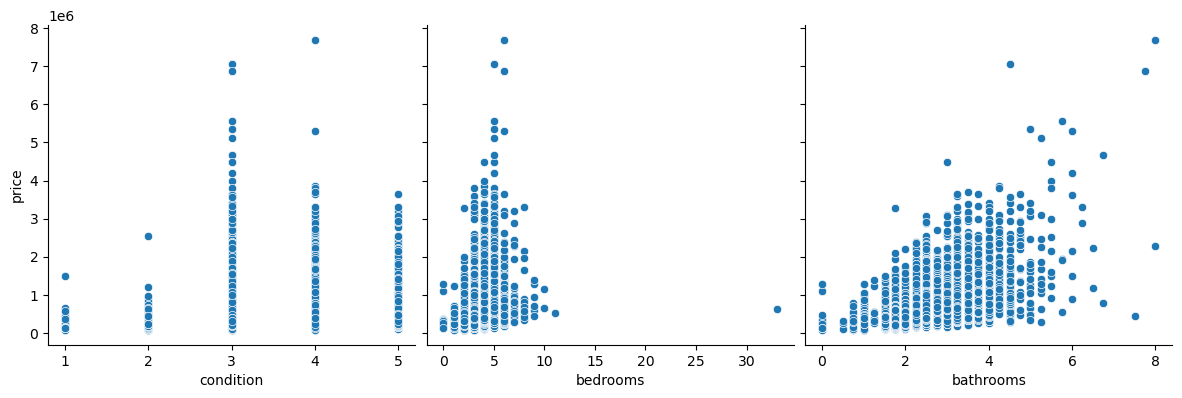

In [4]:
# Quick visualization (help from ChatGPT)
sns.pairplot(df, x_vars=["condition", "bedrooms", "bathrooms"], y_vars="price", height=4)
plt.show()

In [5]:
# Check for null values
print(df.isnull().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


## 2. Feature Engineering & Preprocessing

We drop `id` (non-informative identifier) and `date` (difficult to quantify
meaningfully in regression without further time-series engineering).

All remaining numerical features are then standardised using `StandardScaler`
to ensure no single feature dominates due to scale differences.

In [6]:
# Drop irrelevant columns
df = df.drop(["id", "date"], axis=1)
# I understand that prices can change within the year, but I feel like it is hard to quantify it in regression analysis

In [7]:
# Feature-target split , similar to titanic dataset
X = df.drop("price", axis=1)
y = df["price"]

In [8]:
# Normalize numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split

In [9]:
# Train test with the normalised features
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42) 

### Correlation Heatmap

We visualise feature correlations to identify multicollinearity and understand
which features are most related to each other.
Notable: `sqft_living` and `sqft_above` are highly correlated,
as are `condition` and `grade`.

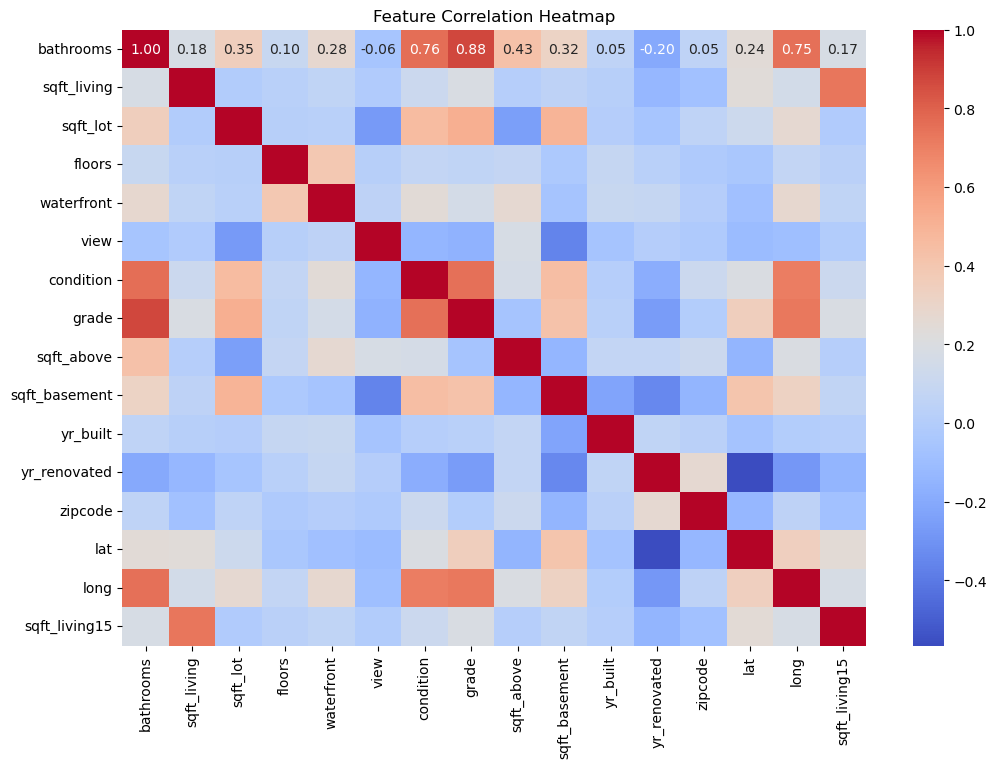

In [10]:
# Convert df to a DataFrame (Help from ChatGPT)
feature_names = df.columns[:-1]  # to exclude target column
X_train_df = pd.DataFrame(X_train, columns=feature_names)

# Select relevant columns for correlation (e.g., columns 3 to 21)
cor_data = X_train_df.iloc[:, 2:21]

# Compute the correlation matrix
correlation = cor_data.corr()

# Visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()

# Model Training & Evaluation

## 3. Model Training & Evaluation

We train two regression models:
- **Linear Regression** — interpretable baseline model
- **Random Forest Regressor** — handles non-linearity and provides feature importance

Evaluation metrics used:
- **RMSE** (Root Mean Squared Error) — penalises large errors more heavily
- **MAE** (Mean Absolute Error) — average magnitude of errors
- **R²** — proportion of variance in price explained by the model

In [11]:
#Linear Regression

logre = LinearRegression()
logre.fit(X_train, y_train)
y_pred_logre = logre.predict(X_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_logre)))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_logre))

Linear Regression RMSE: 212539.51663817756
Linear Regression MAE: 127493.34208656965


In [12]:
#Random Forest Regressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

Random Forest RMSE: 148709.86774445415
Random Forest MAE: 72779.26832132117


## 4. Hyperparameter Tuning (GridSearchCV)

We use 5-fold cross-validation grid search to find the optimal Random Forest
parameters, tuning:
- `n_estimators` (number of trees): [100, 200, 300]
- `max_depth` (tree depth): [10, 20, None]
- `min_samples_split` (minimum samples to split a node): [2, 5, 10]

In [13]:
#Optimisation

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],

}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1, verbose=3)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Tuned Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best_rf)))
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Tuned Random Forest RMSE: 146988.6516996706
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}


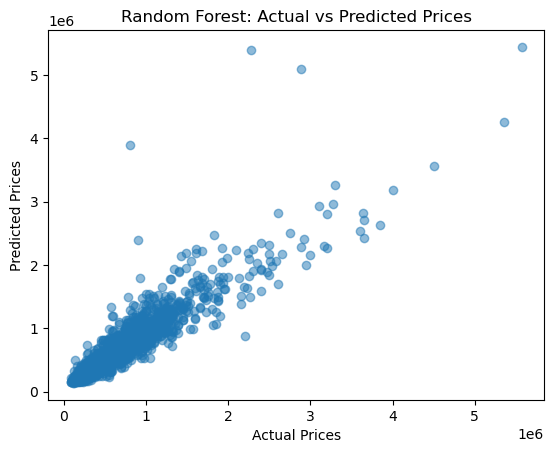

In [14]:
#Displaying the results 
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.show()

# Feature Importance

## 5. Feature Importance

We extract feature importances from the optimised Random Forest model
to understand which variables most influence house price predictions.

In [15]:
# Extract feature importance
importances = best_rf.feature_importances_  # Used optimized Random Forest model
feature_names = X_train_df.columns  # Replace with actual feature names
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

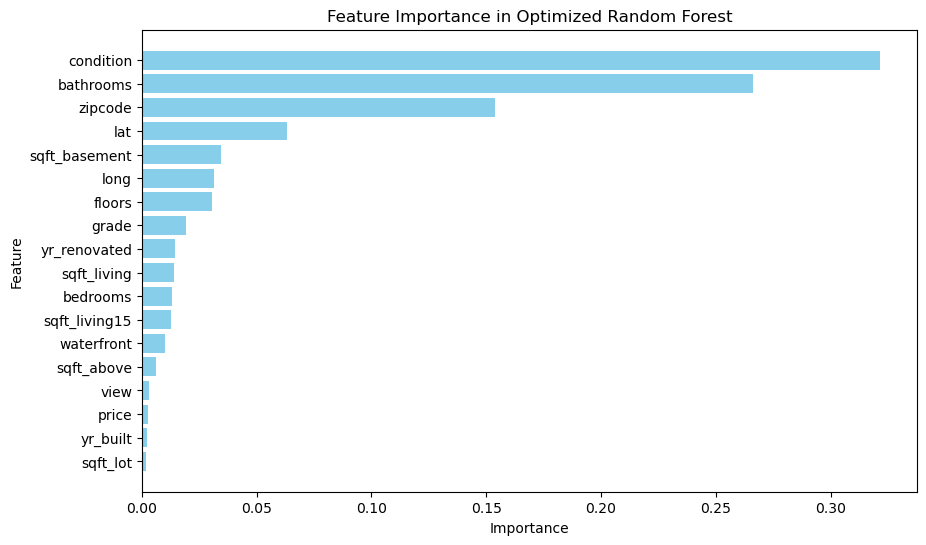

In [16]:
# Sort and plot
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Optimized Random Forest')
plt.gca().invert_yaxis()  # Inverted the y-axis for better readability
plt.show()

In [17]:
# Forgot to import R2 score

from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)

print(f"Optimized Random Forest Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f}")

Optimized Random Forest Performance:
RMSE: 148709.87
R²: 0.85
MAE: 72779.27


## 6. Cross-Validation

To validate model stability, we run 5-fold cross-validation on the training set
and report RMSE scores across folds.

In [18]:
#Trying with Cross Validation

from sklearn.model_selection import cross_val_score

best_rf.set_params(n_estimators=100)  # Reduce number of trees
cv_scores = cross_val_score(best_rf, X_train, y_train, scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=3)
rmse_scores = np.sqrt(-cv_scores)

print(f"Cross-Validated RMSE Scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.2f}, Standard Deviation: {rmse_scores.std():.2f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   14.6s remaining:   22.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   14.8s finished


Cross-Validated RMSE Scores: [143234.48836745 127478.03427256 122735.94585683 119211.61206378
 120230.30746829]
Mean RMSE: 126578.08, Standard Deviation: 8804.17
